# Task 13: Adding Time Limited Immunity

## Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

## Defining helper functions for the simulation

In [2]:
def timed_SIR_sim(N, sim_days, orig_infected, prob_infect, contact_with_people, inf_days, immu_days):
    y0 = N-orig_infected, orig_infected, 0
    beta = prob_infect*contact_with_people
    gamma = 1.0 / inf_days
    v = 1.0/immu_days
    R0 = beta/gamma
    t = np.linspace(0, sim_days-1, sim_days)
    sim_res = odeint(timed_sir_step_ahead, y0, t, args=(N, beta, gamma, v))
    S, I, R = sim_res.T
    return S, I, R, R0

def sim_plot(S, I, R, R0):
    t = np.linspace(0, len(S), len(S))
    plt.title("SIR Simulation (R0= " + str(round(R0, 3)) + ")")
    plt.plot(t, S, label="Susceptible")
    plt.plot(t, I, label="Infected")
    plt.plot(t, R, label="Recovered")
    plt.legend()
    plt.show()

## Timed SIR model implementation

In [3]:
def timed_sir_step_ahead(y, t, N, beta, gamma, v):
    S, I, R = y
    dsdt = -beta * I * (S / N) + v*R
    didt = beta * I * (S / N) - gamma * I
    drdt = gamma * I - v*R
    return dsdt, didt, drdt

## Running the simulation and exploring the results

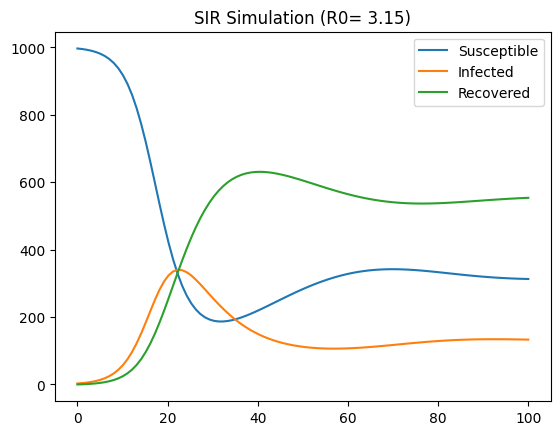

In [4]:
N, sim_days = 1000, 100
orig_infected = 3
prob_infect = 0.15
contact_with_people = 3
inf_days, immu_days = 7, 30

S, I, R, R0 = timed_SIR_sim(N, sim_days, orig_infected, prob_infect, contact_with_people, inf_days, immu_days)
sim_plot(S, I, R, R0)